In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel('datasetHargaTanah.xlsx')

df.head()

,price,bedroom,bathroom,building_area,land_area,latitude,longitude
0,550000000,2,1,50,84,-7.294023,112.587968
1,850000000,2,1,50,60,-7.319864,112.807145
2,500000000,2,2,50,60,-7.257472,112.752088
3,1300000000,2,2,50,74,-7.273916,112.659618
4,900000000,3,2,50,50,-7.257472,112.752088


In [11]:
# ============================================
# EDA (Exploratory Data Analysis)
# ============================================

# 1. Informasi awal data
print("INFO DATASET")
print(df.info())

# 2. Cek data kosong
print("\nJUMLAH DATA KOSONG PER KOLOM:")
print(df.isnull().sum())

# 3. Statistik deskriptif
print("\nSTATISTIK DESKRIPTIF:")
print(df.describe())

# ============================================
# DUPLICATED DATA ANALYSIS
# ============================================

# Definisi duplikat:
# Listing dianggap sama jika lokasi & ukuran sama
duplicate_subset = [
    "latitude",
    "longitude",
    "land_area",
    "building_area"
]

# 4. Jumlah data duplikat
jumlah_duplikat = df.duplicated(
    subset=duplicate_subset
).sum()

print("\nJUMLAH DUPLIKAT LISTING:", jumlah_duplikat)

# 5. Menampilkan data duplikat
df_duplicated = df[
    df.duplicated(
        subset=duplicate_subset
    )
]

print("\nDATA DUPLIKAT:")
print(df_duplicated)

# 6. (Opsional tapi penting) Semua baris duplikat termasuk yang pertama
df_all_duplicates = df[
    df.duplicated(
        subset=duplicate_subset,
        keep=False
    )
]

print("\nSEMUA BARIS DUPLIKAT (TERM. BARIS PERTAMA):")
print(df_all_duplicates)


INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23433 entries, 0 to 23432
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          23433 non-null  int64  
 1   bedroom        23433 non-null  int64  
 2   bathroom       23433 non-null  int64  
 3   building_area  23433 non-null  int64  
 4   land_area      23433 non-null  int64  
 5   latitude       23433 non-null  float64
 6   longitude      23433 non-null  float64
dtypes: float64(2), int64(5)
memory usage: 1.3 MB
None

JUMLAH DATA KOSONG PER KOLOM:
price            0
bedroom          0
bathroom         0
building_area    0
land_area        0
latitude         0
longitude        0
dtype: int64

STATISTIK DESKRIPTIF:
              price       bedroom      bathroom  building_area     land_area  \
count  2.343300e+04  23433.000000  23433.000000   23433.000000  23433.000000   
mean   5.919318e+09      3.754235      2.960867     232.539496    19

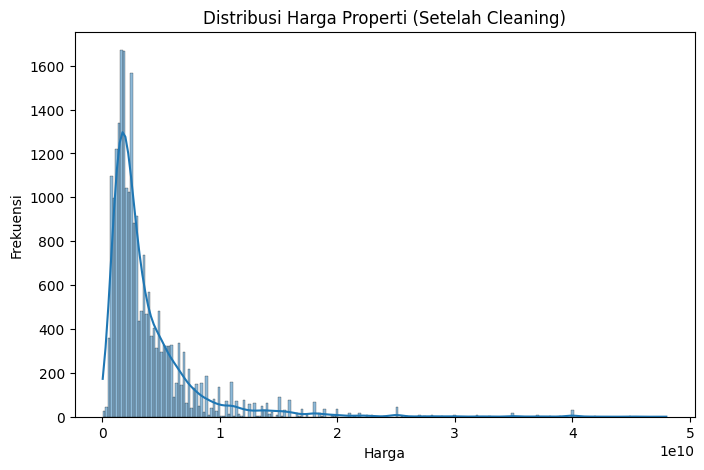

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[
    (df['price'] >= 50_000_000) &   # >= 50 juta
    (df['price'] <= 50_000_000_000) # <= 50 miliar
]


plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], kde=True)
plt.title('Distribusi Harga Properti (Setelah Cleaning)')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()



C:\Users\asus\AppData\Local\Temp\ipykernel_19280\3172124879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['log_price'] = np.log(df_clean['price'])


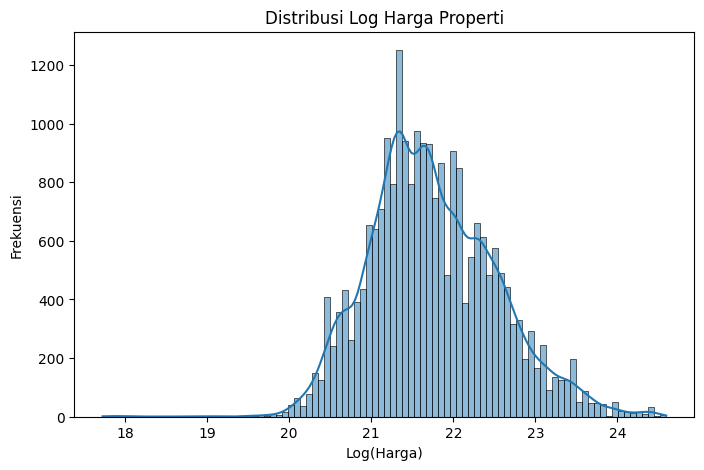

In [15]:
df_clean['log_price'] = np.log(df_clean['price'])

plt.figure(figsize=(8, 5))
sns.histplot(df_clean['log_price'], kde=True)
plt.title('Distribusi Log Harga Properti')
plt.xlabel('Log(Harga)')
plt.ylabel('Frekuensi')
plt.show()


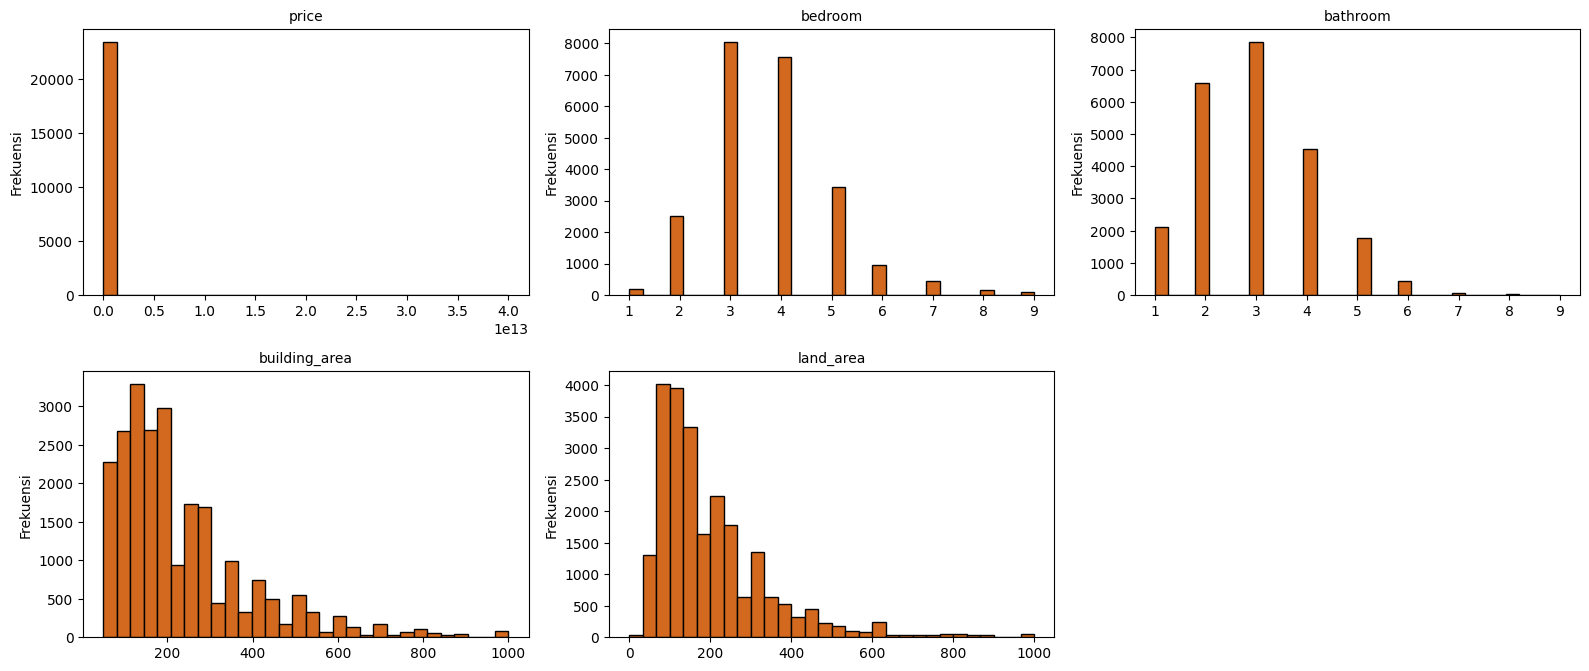

In [19]:
numeric_cols = [
    'price',
    'bedroom',
    'bathroom',
    'building_area',
    'land_area'
]

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # 3x3 cukup untuk 7 kolom
    plt.hist(df[col], bins=30, edgecolor='black', color='chocolate')
    plt.title(col, fontsize=10)
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()
